# Random Forest and Naive Bayes Classifiers

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply random forest classifiers to improve prediction accuracy
- Implement Naive Bayes for text classification tasks
- Evaluate classification models using confusion matrices, ROC curves
- Compare different classification algorithms

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 02 "Bayesian Networks" — Naive Bayes is the simplest such network, put to work as a classifier.

**Used later in:** Course 07 (AIAT 121) — Unit 3, where Naive Bayes is the first classifier applied to real text features.

---

This notebook covers practical activities from **Course 04, Unit 3**:
- Applying random forest classifiers to improve prediction accuracy
- Implementing Naive Bayes for text classification tasks like spam detection
- Evaluating classification models using confusion matrices, ROC curves


## 🌍 A real case: the algorithm that cleaned out the inbox

Naive Bayes assumes every word in a message is independent of every other word given the class. That
is obviously false about language. It worked anyway. Sahami, Dumais, Heckerman and Horvitz set out the
approach in "A Bayesian Approach to Filtering Junk E-Mail" (AAAI-98 workshop), and Paul Graham's essay
"A Plan for Spam" (August 2002) put Bayesian filters into ordinary mail clients within months. It is
the most widely deployed classifier in the history of text, and its central assumption is wrong.

**❗ Why this lesson exists — read the two headline numbers below carefully.** The Random Forest
reaches **test accuracy 0.9972** on fraud. The very next line reports that a model flagging *nothing
at all* would already score **0.9773**. All that work bought 1.99 percentage points. On imbalanced
data, accuracy is a number that flatters you, and the only informative row of the report is the one
for the rare class: precision 1.0000, recall 0.8750 — that is 7 of the 8 real frauds caught, with no
false alarms.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `load("creditcard_fraud", prefer="sample")` — the 16,000-row extract of the real card-transaction
  file that ships with this repository, drawn to preserve the real fraud rate (28 frauds, 0.175%).
  The original holds 284,807 transactions, 492 of them fraudulent.
- `load("montgomery_911_calls", prefer="sample")` — the 25,000-row extract of the real
  emergency-dispatch log, used for the Naive Bayes example. No file paths: the loader finds the data
  from any folder, and on Colab.

**Outputs:** What you'll see when you run the cells

- A Random Forest fraud detector with its classification report, confusion matrix and ROC curve
- A Naive Bayes text classifier that routes real dispatch descriptions to EMS / Fire / Traffic

---

In [1]:
# CELL: Import the two model families compared in this lesson.
# WHY: Random Forest (an ensemble of trees) and Naive Bayes (a probabilistic
# model) represent opposite philosophies - flexible vs. simple-but-fast.
# CountVectorizer turns raw text into word counts for the spam example.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")

Data loader ready - no file paths needed, and this works on Colab too.


## Part 1: Random Forest Classification — Real Credit-Card Fraud

The dataset is the well-known Kaggle credit-card fraud file: 284,807 transactions made by
European cardholders over two days in September 2013, of which **492 are fraudulent** —
0.172% of the rows. Features `V1`-`V28` are anonymized (they are principal components of
the original variables, published this way for privacy), plus the transaction `Amount`.

We read the 16,000-row extract that ships with this repository, drawn to preserve that
rate — so it holds **28 real frauds**, not 492. We keep every one of them and take 41
legitimate transactions per fraud (1,148 rows), which leaves the data unbalanced enough to
be honest (**1 fraud in 42**, exactly the working balance this lesson is built on) while
staying fast enough for a classroom. **Watch what that imbalance does to accuracy** in the
report below.

⚠️ **Know the resolution of your own experiment.** A 70/30 split of 1,176 rows puts **8
frauds** in the test set. Recall can therefore only be 0, 1/8, 2/8 … and AUC moves in
visible steps. Every fraud number in this notebook is honest, and none of it is precise to
three decimals. Download the full file (Course 04/datasets/DATA.md) when you need precision.


In [3]:
# Load REAL transaction data and train a Random Forest on it.
# WHY only some columns: the original file is 150 MB; V1-V10 plus Amount is enough for a
# classroom demo and keeps the read under a second.
# WHY load(...) instead of a path: it finds the data from any working directory - your
# laptop, JupyterLab opened at the repository root, or Colab where there is no repository -
# and prints which copy it used. prefer="sample" reads the 16,000-row extract that ships in
# the repository, drawn to preserve the real fraud RATE, so every reader sees these numbers.
from sklearn.metrics import accuracy_score

feature_cols = [f"V{i}" for i in range(1, 11)] + ["Amount"]
transactions = load("creditcard_fraud", prefer="sample",
                    usecols=feature_cols + ["Class"])

print(f"Rows read: {len(transactions):,} transactions, "
      f"{int(transactions['Class'].sum())} of them fraudulent "
      f"({transactions['Class'].mean():.3%})")

# Keep every fraud; take a random sample of legitimate transactions to classroom-size it.
# 41 legitimate rows per fraud reproduces the 1-in-42 working balance this lesson is built
# on: 28 frauds in the bundled sample x 41 = 1,148 legitimate rows.
frauds = transactions[transactions["Class"] == 1]
legit = transactions[transactions["Class"] == 0].sample(n=1_148, random_state=42)
sample = pd.concat([frauds, legit]).sample(frac=1.0, random_state=42)   # shuffle

X = sample[feature_cols].to_numpy()
y = sample["Class"].to_numpy()
print(f"Working sample: {len(sample):,} transactions, {y.sum()} frauds "
      f"({y.mean():.2%}) — still genuinely unbalanced")

# stratify=y keeps the same fraud rate in both halves; without it a rare class can
# land almost entirely on one side of the split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train a Random Forest classifier (an ensemble of decision trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions: class labels and probabilities for the positive class
rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("Random Forest Classification:")
print("=" * 60)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Test accuracy: {rf.score(X_test, y_test):.4f}")
print(f"...but a model that flagged NOTHING as fraud would already score "
      f"{(y_test == 0).mean():.4f}")
print("\nClassification Report (0 = legitimate, 1 = fraud):")
print(classification_report(y_test, rf_pred, digits=4))
print("Read the fraud row, not the accuracy: precision says how many flagged")
print("transactions really were fraud, recall says how many frauds we caught.")

creditcard_fraud: bundled 16,000-row sample of the 284,807-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified so the fraud rate stays 0.175% (28 fraud rows) against 0.173% in the full file; V1-V28 and Amount rounded to 6 decimals.
Rows read: 16,000 transactions, 28 of them fraudulent (0.175%)
Working sample: 1,176 transactions, 28 frauds (2.38%) — still genuinely unbalanced
Random Forest Classification:
Training samples: 823, Test samples: 353
Test accuracy: 0.9972
...but a model that flagged NOTHING as fraud would already score 0.9773

Classification Report (0 = legitimate, 1 = fraud):
              precision    recall  f1-score   support

           0     0.9971    1.0000    0.9986       345
           1     1.0000    0.8750    0.9333         8

    accuracy                         0.9972       353
   macro avg     0.9986    0.9375    0.9659       353
weighte

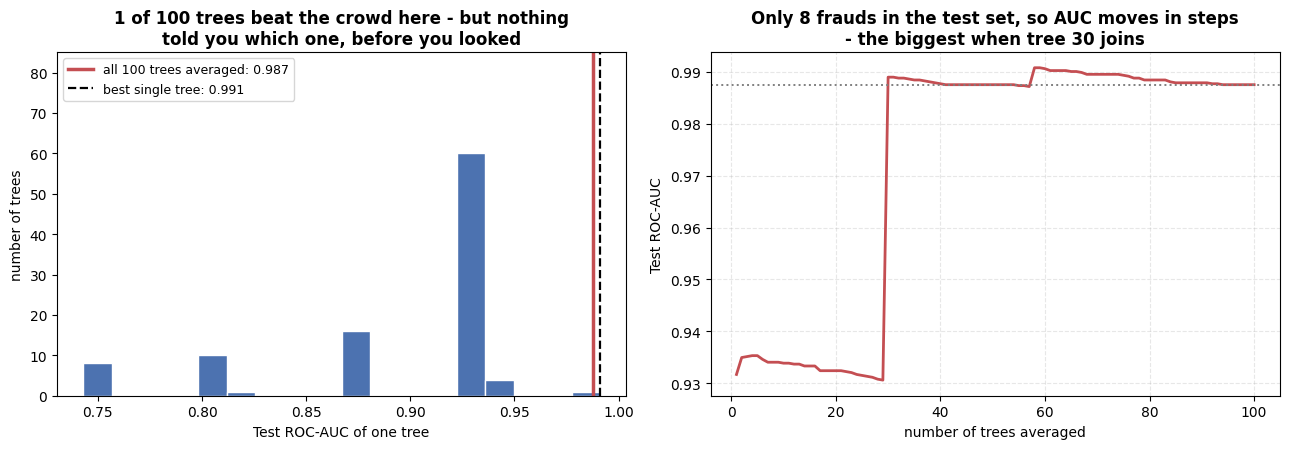


📊 Step table: how AUC grows as trees are added
  trees   test ROC-AUC
-----------------------
      1         0.9317
      2         0.9350
      5         0.9353
     10         0.9339
     25         0.9315
     50         0.9875
    100         0.9875

 Single trees: worst 0.7428, median 0.9288, best 0.9913
 The 100-tree crowd: 0.9875  - above 99 of the 100 trees.
 Health warning: the test set holds only 8 frauds, so the true-positive axis has
 8 rungs and one fraud row is worth up to 12.5 AUC points. Read the SPREAD of
 the trees, not third decimal places.
 The 100-tree average reproduces rf.predict_proba to within 0.00e+00
 - so this really is the same model, taken apart.


In [4]:
# CELL: Show that the "forest" part is doing the work, not the "tree" part.
# WHY: this notebook trains 100 trees and never shows what the 100 buys you.
# The 100 trees are already fitted, so this costs no extra training - we just
# score them one at a time and then average them one at a time.

# Each fitted tree's own probability for every test transaction: (n_test, 100)
tree_probs = np.column_stack([t.predict_proba(X_test)[:, 1] for t in rf.estimators_])
single_aucs = np.array([roc_auc_score(y_test, tree_probs[:, i])
                        for i in range(tree_probs.shape[1])])

# Averaging the first n trees IS what a forest of n trees predicts.
running_mean = np.cumsum(tree_probs, axis=1) / np.arange(1, tree_probs.shape[1] + 1)
auc_by_n = np.array([roc_auc_score(y_test, running_mean[:, i])
                     for i in range(running_mean.shape[1])])
forest_auc = roc_auc_score(y_test, rf_pred_proba)

# Titles are COMPUTED from the numbers, never asserted, so the picture can never
# contradict its own caption. n_beat counts trees that matched or beat the crowd.
n_beat = int((single_aucs >= forest_auc).sum())
title_left = ("Not one of the 100 trees is as good as the crowd" if n_beat == 0 else
              f"{n_beat} of 100 trees beat the crowd here - but nothing\ntold you which one, before you looked")
jump_at = int(np.argmax(np.diff(auc_by_n))) + 2          # the tree whose arrival moved AUC most
n_pos = int(y_test.sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Panel 1: every individual tree, and the crowd
ax = axes[0]
ax.hist(single_aucs, bins=18, color='#4C72B0', edgecolor='white')
ax.axvline(forest_auc, color='#C44E52', linewidth=2.5,
           label=f'all 100 trees averaged: {forest_auc:.3f}')
ax.axvline(single_aucs.max(), color='black', linestyle='--', linewidth=1.6,
           label=f'best single tree: {single_aucs.max():.3f}')
ax.set_xlabel('Test ROC-AUC of one tree')
ax.set_ylabel('number of trees')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # counts are whole numbers
ax.set_title(title_left, fontsize=12, fontweight='bold')
ax.set_ylim(0, ax.get_ylim()[1] * 1.35)   # headroom so the legend clears the bars
ax.legend(fontsize=9, loc='upper left')

# --- Panel 2: watch the crowd converge as trees are added
ax = axes[1]
ax.plot(np.arange(1, len(auc_by_n) + 1), auc_by_n, color='#C44E52', linewidth=2)
ax.axhline(forest_auc, color='gray', linestyle=':', linewidth=1.4)
ax.set_xlabel('number of trees averaged')
ax.set_ylabel('Test ROC-AUC')
ax.set_title(f'Only {n_pos} frauds in the test set, so AUC moves in steps\n'
             f'- the biggest when tree {jump_at} joins',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')

fig.tight_layout()
plt.show()

print("\n📊 Step table: how AUC grows as trees are added")
print(f"{'trees':>7} {'test ROC-AUC':>14}")
print("-" * 23)
for n in [1, 2, 5, 10, 25, 50, 100]:
    print(f"{n:>7d} {auc_by_n[n - 1]:>14.4f}")
print(f"\n Single trees: worst {single_aucs.min():.4f}, "
      f"median {np.median(single_aucs):.4f}, best {single_aucs.max():.4f}")
print(f" The 100-tree crowd: {forest_auc:.4f}  - above {100 - n_beat} of the 100 trees.")
print(f" Health warning: the test set holds only {n_pos} frauds, so the true-positive"
      f" axis has\n {n_pos} rungs and one fraud row is worth up to"
      f" {100 / n_pos:.1f} AUC points. Read the SPREAD of\n the trees, not third"
      " decimal places.")
print(f" The 100-tree average reproduces rf.predict_proba to within "
      f"{np.abs(running_mean[:, -1] - rf_pred_proba).max():.2e}")
print(" - so this really is the same model, taken apart.")


**Read the figure.** Left: each bar counts trees that scored in that AUC range on their own. The spread is the point — the worst tree scores **0.7428**, the median **0.9288**, the best **0.9913**, all from the same data and the same algorithm, differing only in which rows and columns each one happened to see. The red line is the crowd, **0.9875**, and it sits above 99 of the 100 bars.

One tree beat it. Look at the black dashed line: tree #29 scored 0.9913. That is not an argument against ensembling — it is the argument *for* it. Nothing on this histogram was visible before the test set was scored; you could not have picked tree #29 in advance, and on the next batch of transactions it will not be the winner. The crowd needs no such luck.

Right: the same 100 trees added one at a time. The curve sits flat near 0.933, then jumps to 0.989 the moment tree #29 joins the average, then settles. That step is not a property of ensembles; it is a property of a test set with **8 fraud cases in it**. With 8 positives the true-positive axis has 8 rungs, so a single fraud row changing places is worth up to 12.5 AUC points. Read the step table for the numbers, read the histogram for the lesson, and do not read the third decimal place of anything here.

## Part 2: Naive Bayes for Text Classification — Routing Real 911 Calls

Naive Bayes on word counts is the classic spam-filter algorithm, and it is used here on
real text of the same shape: the short description a dispatcher types for each 911 call
(`"CARDIAC EMERGENCY"`, `"VEHICLE ACCIDENT"`, `"GAS-ODOR/LEAK"`). Every call in the
Montgomery County log carries a category — **EMS**, **Fire** or **Traffic** — so we can
train on real descriptions and check the model against the real routing decision.

Same algorithm, same `CountVectorizer` pipeline a spam filter uses; only the labels differ.


In [5]:
# Naive Bayes on REAL dispatch text: route an incident description to EMS / Fire / Traffic.
# WHY this task: it is exactly the spam-filter recipe (word counts -> MultinomialNB), but
# on text a human actually typed under time pressure, with the abbreviations to prove it.
# prefer="sample" reads the 25,000-row extract of the dispatch log that ships inside the
# repository - 1 call in every 27, evenly spread, so it still spans 2015-2020 and still
# contains all 100 distinct call types. Everyone therefore trains on the same text.
calls = load("montgomery_911_calls", prefer="sample", usecols=["title"])

# Each title looks like "EMS: BACK PAINS/INJURY" — category before the colon,
# description after it. We train on the description and predict the category.
category = calls["title"].str.split(":").str[0].str.strip()
description = calls["title"].str.split(":").str[1].str.strip()
keep = description.notna()
description, category = description[keep], category[keep]

print(f"Real calls loaded: {len(description):,}")
print(f"Categories: {category.value_counts().to_dict()}")
print(f"Example descriptions: {description.head(4).tolist()}")

text_train, text_test, y_train_txt, y_test_txt = train_test_split(
    description, category, test_size=0.3, random_state=42, stratify=category)

# Convert text into word-count features (fit on the TRAINING text only)
vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(text_train)
X_text_test = vectorizer.transform(text_test)

# Train a Multinomial Naive Bayes classifier (well suited to word counts)
nb_model = MultinomialNB()
nb_model.fit(X_text, y_train_txt)

print("=" * 60)
print("Naive Bayes call routing:")
print("=" * 60)
print(f"Vocabulary learned: {len(vectorizer.vocabulary_)} distinct words")
print(f"Test accuracy on {len(text_test):,} held-out calls: "
      f"{nb_model.score(X_text_test, y_test_txt):.4f}")
print("\nPer-category report:")
print(classification_report(y_test_txt, nb_model.predict(X_text_test), digits=3))

# Classify descriptions the model has never seen, written the way a dispatcher would.
new_calls = ["CARDIAC ARREST", "VEHICLE ACCIDENT", "BUILDING FIRE", "unconscious subject"]
new_X = vectorizer.transform(new_calls)
nb_pred = nb_model.predict(new_X)
nb_proba = nb_model.predict_proba(new_X)

print("Routing four unseen descriptions:")
for text, pred, proba in zip(new_calls, nb_pred, nb_proba):
    print(f"  '{text}' -> {pred} (confidence: {proba.max():.4f})")

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
Real calls loaded: 25,000
Categories: {'EMS': 12613, 'Traffic': 8678, 'Fire': 3709}
Example descriptions: ['HEAD INJURY', 'ROAD OBSTRUCTION -', 'VEHICLE ACCIDENT -', 'FIRE ALARM']
Naive Bayes call routing:
Vocabulary learned: 112 distinct words
Test accuracy on 7,500 held-out calls: 0.9269

Per-category report:
              precision    recall  f1-score   support

         EMS      0.993     0.909     0.949      3784
        Fire      0.924     0.858     0.890      1113
     Traffic      0.852     0.983     0.913      2603

    accuracy                          0.927      7500
   macro avg      0.923     0.917     0.917    

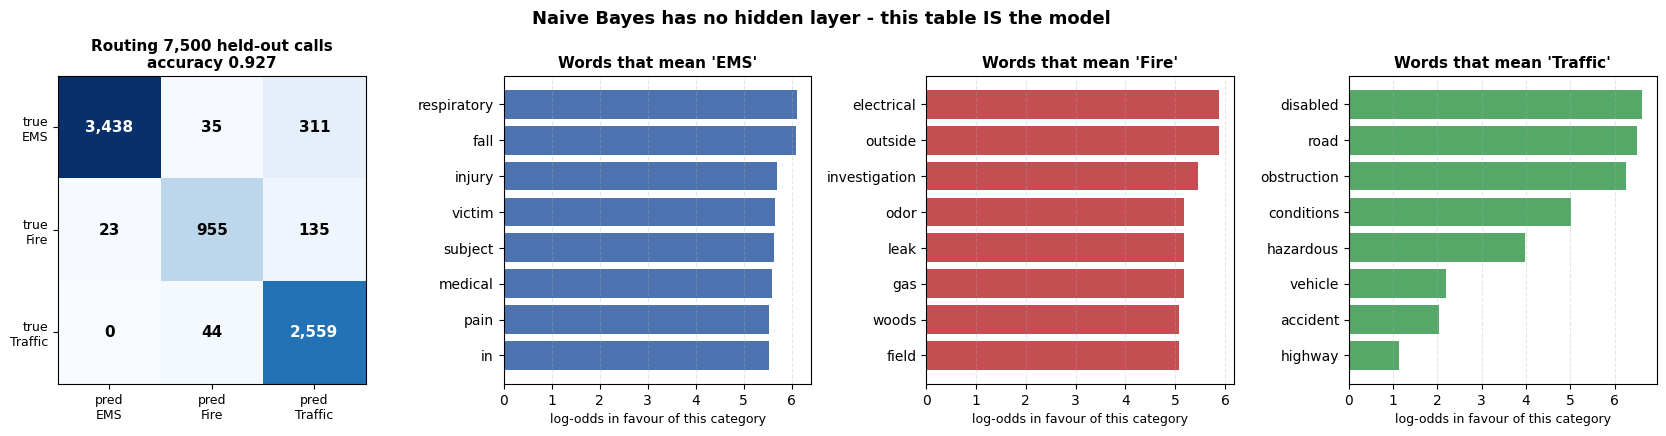


📊 The top evidence word for each category, with its log-odds:
  EMS        'respiratory'  +6.11
  Fire       'electrical'  +5.89
  Traffic    'disabled'  +6.62

💡 A positive bar means: seeing this word makes that category more likely.
   Naive Bayes simply adds these numbers up over the words in the call text.


In [6]:
# CELL: Show what Naive Bayes actually learned, not just how often it is right.
# WHY: the whole appeal of this model is that its "reasoning" is a table of word
# probabilities you can read. feature_log_prob_ IS that table - one row per
# category, one column per vocabulary word.

vocab = np.array(vectorizer.get_feature_names_out())
log_prob = nb_model.feature_log_prob_        # shape: (3 categories, n_words)
classes = list(nb_model.classes_)

# How much MORE likely is a word under this category than under the others?
# (log space, so this subtraction is a ratio.) That is the evidence the model
# adds up when it routes a call.
others_mean = np.array([np.delete(log_prob, i, axis=0).mean(axis=0)
                        for i in range(len(classes))])
evidence = log_prob - others_mean

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4),
                         gridspec_kw={'width_ratios': [1.15, 1, 1, 1]})

# --- Panel 1: where the routing goes wrong
y_pred_txt = nb_model.predict(X_text_test)
cm_txt = confusion_matrix(y_test_txt, y_pred_txt, labels=classes)
ax = axes[0]
ax.imshow(cm_txt, cmap="Blues")
ax.set_xticks(range(len(classes)), labels=[f"pred\n{c}" for c in classes], fontsize=9)
ax.set_yticks(range(len(classes)), labels=[f"true\n{c}" for c in classes], fontsize=9)
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f"{cm_txt[i, j]:,}", ha="center", va="center", fontsize=11,
                fontweight="bold",
                color="white" if cm_txt[i, j] > cm_txt.max() / 2 else "black")
ax.set_title(f"Routing {len(y_test_txt):,} held-out calls\n"
             f"accuracy {nb_model.score(X_text_test, y_test_txt):.3f}",
             fontsize=11, fontweight="bold")

# --- Panels 2-4: the words that decide each category
bar_colors = ['#4C72B0', '#C44E52', '#55A868']
for ax, ci, colr in zip(axes[1:], range(len(classes)), bar_colors):
    top = np.argsort(evidence[ci])[-8:]          # 8 most category-specific words
    ax.barh(range(len(top)), evidence[ci][top], color=colr)
    ax.set_yticks(range(len(top)), labels=vocab[top], fontsize=10)
    ax.set_xlabel('log-odds in favour of this category', fontsize=9)
    ax.set_title(f"Words that mean '{classes[ci]}'", fontsize=11, fontweight="bold")
    ax.grid(axis='x', alpha=0.3, linestyle='--')

fig.suptitle("Naive Bayes has no hidden layer - this table IS the model",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print("\n📊 The top evidence word for each category, with its log-odds:")
for ci, c in enumerate(classes):
    j = int(np.argmax(evidence[ci]))
    print(f"  {c:<10} '{vocab[j]}'  {evidence[ci][j]:+.2f}")
print("\n💡 A positive bar means: seeing this word makes that category more likely.")
print("   Naive Bayes simply adds these numbers up over the words in the call text.")


**Read the figure.** The left panel is the routing decision on held-out calls: the diagonal is what went to the right desk, everything off it went to the wrong one. Look at which off-diagonal cells are largest — that pair of categories is where the vocabulary genuinely overlaps.

The three bar panels are the model itself. Each bar is a word, and its length is how much more likely that word is under this category than under the other two. This is not an explanation bolted on afterwards; it is the actual arithmetic — Naive Bayes adds these numbers up over the words in a call description and picks the largest total. Read the words out loud and you can audit it. Most are exactly what you would hope for - but look at 'in' sitting in the EMS list, a word with no medical content that simply happens to appear in EMS phrasing. That is the model latching onto surface form rather than meaning, and spotting it in a bar chart is why this figure is worth drawing at all.

## Part 3: Evaluation Metrics - Confusion Matrix and ROC Curve

Back to the fraud detector. On data this unbalanced the four confusion-matrix cells matter
far more than the single accuracy number: every **false negative** is a fraud that went
through, and every **false positive** is a customer whose legitimate card got blocked.


ROC Curve Analysis:
ROC AUC Score: 0.9875
True Positive Rate at FPR=0.2: 1.0000

Confusion Matrix Interpretation:
True Negatives (TN): 345
False Positives (FP): 0
False Negatives (FN): 1
True Positives (TP): 7

Precision: 1.0000
Recall: 0.8750
F1-Score: 0.9333


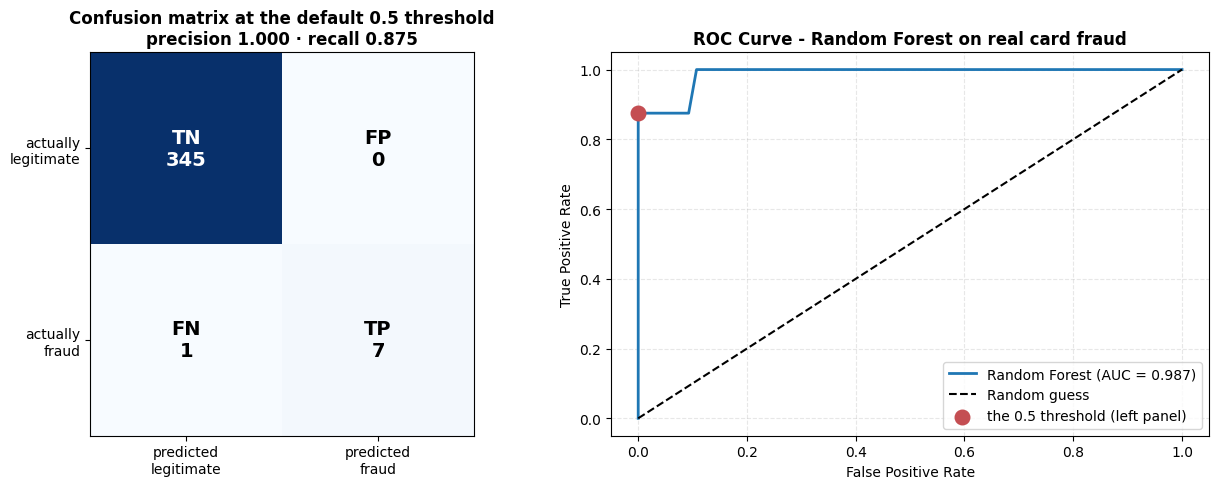

In [7]:
# ROC Curve for Random Forest
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_proba)
roc_auc = auc(fpr, tpr)
print("=" * 60)
print("ROC Curve Analysis:")
print("=" * 60)
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"True Positive Rate at FPR=0.2: {np.interp(0.2, fpr, tpr):.4f}")

# Confusion matrix interpretation
cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print(f"\nPrecision: {tp/(tp+fp):.4f}")
print(f"Recall: {tp/(tp+fn):.4f}")
print(f"F1-Score: {2*tp/(2*tp+fp+fn):.4f}")


# Draw both halves of the story: WHERE the errors fall, and how the model
# trades one kind of error for the other as the threshold moves.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: the confusion matrix the markdown above talks about
ax = axes[0]
im = ax.imshow(cm, cmap="Blues")
labels = ["legitimate", "fraud"]
ax.set_xticks([0, 1], labels=[f"predicted\n{t}" for t in labels])
ax.set_yticks([0, 1], labels=[f"actually\n{t}" for t in labels])
names = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        # white text on the dark cell, black on the pale ones
        ax.text(j, i, f"{names[i][j]}\n{cm[i, j]:,}", ha="center", va="center",
                fontsize=14, fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title(f"Confusion matrix at the default 0.5 threshold\n"
             f"precision {tp/(tp+fp):.3f} · recall {tp/(tp+fn):.3f}",
             fontsize=12, fontweight="bold")

# --- Panel 2: the ROC curve (unchanged content, now beside its matrix)
ax = axes[1]
ax.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
# mark the operating point the confusion matrix on the left corresponds to
ax.scatter([fp / (fp + tn)], [tp / (tp + fn)], s=110, color="#C44E52", zorder=5,
           label="the 0.5 threshold (left panel)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Random Forest on real card fraud",
             fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3, linestyle="--")

fig.tight_layout()
plt.show()


**Read the figure.** Left, the four cells the section above insists on. TN is huge and TP is small — that is what a 1-in-42 fraud rate looks like, and it is exactly why the accuracy number printed further up is useless here. The two cells to watch are FN (frauds that went through) and FP (real customers whose card got blocked); the precision and recall in the panel title are just those two cells, rewritten.

Right, the same model at *every* threshold instead of just 0.5. The red dot marks the exact operating point the left panel counts, and it sits hard against the left edge — this forest catches most fraud while barely touching legitimate traffic. Moving the dot up that steep left edge costs almost nothing; moving it along the long flat stretch to the right costs a great deal for very little extra recall.

## 💬 Discuss

From the confusion matrix: TN **345**, FP **0**, FN **1**, TP **7**. Naive Bayes call routing:
accuracy **0.9269**, per-category recall EMS 0.909, Fire 0.858, Traffic 0.983.

1. **Put money on the errors.** The forest catches 7 of the 8 frauds and raises no false alarms; the
   do-nothing model catches 0 and raises 0. If a missed fraud averages 1,000 SAR and a false alarm
   costs 20 SAR of support time, which model wins? Now set the false-alarm cost to 200 SAR and
   recompute. Does your recommendation flip, and at what exchange rate between the two errors does it
   flip exactly? Then answer the awkward part: with **zero** false positives observed, what is the
   most honest thing you can say about this model's false-alarm rate in production?

2. **`'unconscious subject'` is routed to EMS with confidence 0.9999**, from a vocabulary of 112
   words. Is that confidence real? Explain what a probability of 0.9999 can possibly mean from a model
   whose independence assumption you already know is false — and what you would show a dispatcher
   instead of that number.

3. **Fire recall is 0.858** — roughly one fire call in seven is routed elsewhere; EMS recall is 0.909;
   Traffic recall is 0.983. Unlike the fraud numbers, these rest on 7,500 held-out calls, so they are
   measured, not estimated. You have one week. Do you spend it lifting overall accuracy from 92.7% to
   95%, or lifting Fire recall alone? Justify with consequences, not with metrics.

## Summary

### Key Concepts:
1. **Random Forest**: Ensemble of decision trees, reduces overfitting
2. **Naive Bayes**: Probabilistic classifier, excellent for text classification
3. **Confusion Matrix**: Shows TP, TN, FP, FN for detailed evaluation
4. **ROC Curve**: Plots TPR vs FPR, AUC score summarizes performance

### Applications:
- Random Forest: general tabular classification — here, real card-fraud detection
- Naive Bayes: spam detection, text classification, document categorization — here, routing real 911 call descriptions

### What the real data added:
- **Accuracy lied.** Flagging nothing as fraud already scores 0.9773 on the test split; only precision, recall and AUC show whether the model is doing anything.
- **Sample size is part of the result.** 8 frauds in the test split means recall lands on eighths and AUC moves in steps. The lesson survives; the third decimal place does not.
- **Text is messy.** Dispatchers write in abbreviations and slashes, and the vocabulary is tiny compared with prose — Naive Bayes copes because word counts are all it ever needed.

**Reference:** Course 04, Unit 3: "Applying random forest classifiers" and "Implementing Naive Bayes for text classification"


## ⚠️ Where this breaks

- **Naive Bayes' probabilities are systematically extreme.** It multiplies per-word probabilities as
  though the words were independent, so evidence gets counted several times over and confidences pile
  up at 0 and 1. Treat its **ranking** as informative and its **probability** as decoration — or
  calibrate it explicitly before anyone acts on the number.
- **It only knows the words it saw.** The vocabulary here is 112 words. A dispatcher who types a
  phrasing that never appeared in training contributes nothing to the decision, and the model will not
  tell you that it is guessing.
- **Random Forest's limit is the mirror image.** It is the more accurate model here and you cannot
  show a fraud investigator why *this* transaction was flagged. Feature importances describe the
  forest as a whole, not the case in front of you.
- **The assumption that must hold for the fraud result:** that fraud in a two-day capture from
  September 2013 resembles fraud today. It does not. Fraud adapts specifically to whatever is
  currently being detected, which is why production fraud models are retrained continuously and
  monitored for drift — the one thing this notebook cannot demonstrate.
- **The cheaper alternative for text:** a linear model on TF-IDF features (`LogisticRegression` or
  `LinearSVC`) usually beats Naive Bayes on accuracy *and* gives usable probabilities, for a few
  seconds more training. Naive Bayes earns its place when training data is tiny, when you need it to
  train in milliseconds, or when it must update online, one message at a time.


## 📚 References

1. Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32.
2. Domingos, P., & Pazzani, M. (1997). *On the Optimality of the Simple Bayesian Classifier under Zero-One Loss*. Machine Learning, 29, 103–130.
3. Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why Do Tree-Based Models Still Outperform Deep Learning on Tabular Data?* NeurIPS 2022 Datasets and Benchmarks. <https://arxiv.org/abs/2207.08815>
4. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. <https://arxiv.org/abs/2506.16791>
5. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. <https://arxiv.org/abs/2511.08667>
